<h2 id="%ED%95%B5%EC%8B%AC%EA%B0%9C%EB%85%90">핵심개념¶</h2>
정규화* , 표준화* ,  다중회귀 , EDA 시각화* , 다항회귀

In [114]:
#!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import warnings as wr
wr.filterwarnings(action='ignore')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
#이미지를 읽어 들이기 위한 라이브러리 추가
import matplotlib.image as mpimg
import matplotlib as mpl
from PIL import Image
import seaborn as sns
import os
font_list = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
#한글처리 -> 코랩에서는 별도로 다시 강의 
plt.rcParams['font.family'] ="NanumGothic"
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False
#MLModel
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing
from sklearn.model_selection import train_test_split #데이터 분할 모듈

<p>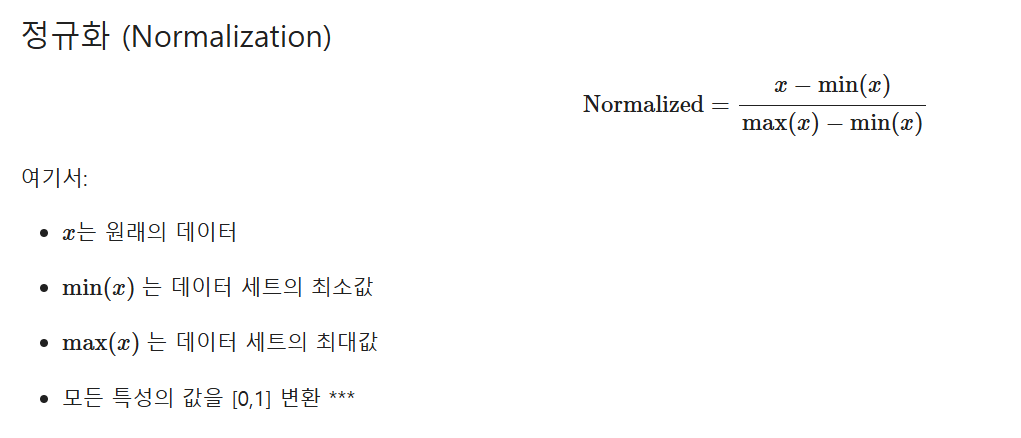</p>

In [3]:
# 임의의 특성 만들기 - 스케일이 큰 데이터를 생성 해보았다.
feature = np.array([[-500.5],[-100.1],[0],[100.1],[900.9]])
feature

array([[-500.5],
       [-100.1],
       [   0. ],
       [ 100.1],
       [ 900.9]])

In [6]:
# 공식을 적용해서 우리가 굴한 Normalized 스케일링
min_feature = np.min(feature)
max_feature = np.max(feature)
normalized_feature = (feature - min_feature) / (max_feature - min_feature)
# 일반적으로 0 ~ 1 이나 -1 ~ 1 사이 값
print(f'정규화 적용 : {normalized_feature}')

정규화 적용 : [[0.        ]
 [0.28571429]
 [0.35714286]
 [0.42857143]
 [1.        ]]


In [12]:
# 사이킷 런의 MinMaxScaler , 기본값 0 ~ 1사이 => import preprocessing 가지고 있는 객체
from sklearn import preprocessing
minmax_Scaler = preprocessing.MinMaxScaler()
print(minmax_Scaler)

MinMaxScaler()


In [13]:
# nor_fit = minmax_Scaler.fit(feature)
# nor_fit

In [14]:
# nor_feature = nor_fit.transform(feature)
# nor_feature

In [15]:
# fit_transform(X) => fit,transform 동일
nor_feature2 = minmax_Scaler.fit_transform(feature)
nor_feature2

array([[0.        ],
       [0.28571429],
       [0.35714286],
       [0.42857143],
       [1.        ]])

<h2 id="%ED%91%9C%EC%A4%80%ED%99%94%EC%99%80-%EC%A0%95%EA%B7%9C%ED%99%94-%EC%9E%A5%EC%A0%90-(%EB%A9%B4%EC%A0%91-%EB%8C%80%EB%B9%84)">표준화와 정규화 장점¶</h2>
<p>최적화 알고리즘의 수렴 속도를 향상 시킨다</p>

<p>과적합을 방지 : 특정 특성에 지나치게 의존 하지 않도록 하는것 까지 포함</p>

<p>이상치가 있는 경우에 모델이 민감하게 반응하는데 표준화로 해주면 이상치 마저도 범위가 조정 되어 버려서 민감하지 않는 특성을 가진 모델로 만들어 준다.</p>

<p>표준화 같은 경우에는 표준편차를 이용하기 때문에 극단적인 값의 영향이 생기지 않도록 조정해준다.</p>

In [16]:
os.listdir('dataset')

['linear.csv', 'rabbit.jpg']

In [18]:
img_path = 'dataset/five.png'
oimage = Image.open(img_path)
type(oimage)

PIL.PngImagePlugin.PngImageFile

In [19]:
np.array(oimage).shape

(120, 120, 4)

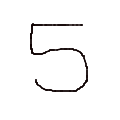

In [20]:
oimage

In [21]:
#image의 크기를 120x120으로 변환
oo_image = oimage.resize((120,120))
gray_img = oo_image.convert('L')
img_array = np.array(gray_img)
img_array.shape

(120, 120)

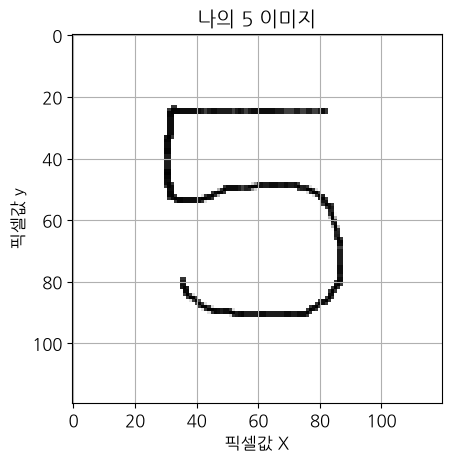

In [22]:
#image를 읽어올때는 Image.open()
#image를 출력 : plt.imshow()
plt.imshow(img_array,cmap='gray')
plt.title('나의 5 이미지')
plt.xlabel('픽셀값 X')
plt.ylabel('픽셀값 y')
plt.grid(True)
plt.show()

<p>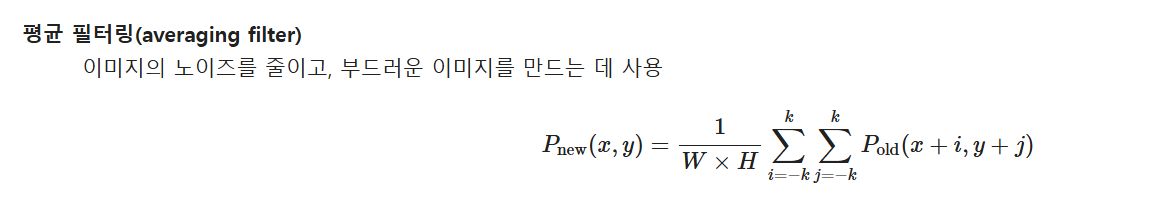</p>

In [23]:
## 이미지 처리를 위한 평균 필터링
## img_array 의 크기에서 W, H 구해보자.
height, width = img_array.shape
height, width

(120, 120)

In [24]:
#필터의 크기 : 120 x 120 -> 12 x 12
W,H = 10,10
height // W , width // H

(12, 12)

In [25]:
# 12x12의 0벡터 생성 
filter_image = np.zeros((height // W , width // H))
filter_image

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [26]:
# 이미지를 반복하면사 필터를 적용해서 평균 값을 계산 해내는 공식
# 이미지 오른쪽 상단에서 부터 하단 끝까지 하나씩 이동하면서
# 필터의 평균을 구하는데 (12x12) 이미지에 값을 하나씩 저장할 예정
for i in range(0,height,W):
    for j in range(0,width,H):
        #print(img_array[i:i+W , j:j+H])
        c_window = img_array[i:i+W , j:j+H]
        filter_image[i//W,j//H] = np.mean(c_window)

In [27]:
np.array(img_array).shape , filter_image.shape

((120, 120), (12, 12))

In [28]:
filter_image

array([[255.  , 255.  , 255.  , 255.  , 255.  , 255.  , 255.  , 255.  ,
        255.  , 255.  , 255.  , 255.  ],
       [255.  , 255.  , 255.  , 255.  , 255.  , 255.  , 255.  , 255.  ,
        255.  , 255.  , 255.  , 255.  ],
       [255.  , 255.  , 255.  , 188.93, 210.1 , 211.1 , 209.5 , 214.8 ,
        241.84, 255.  , 255.  , 255.  ],
       [255.  , 255.  , 255.  , 205.45, 255.  , 255.  , 255.  , 255.  ,
        255.  , 255.  , 255.  , 255.  ],
       [255.  , 255.  , 255.  , 204.06, 253.02, 230.38, 209.08, 230.3 ,
        255.  , 255.  , 255.  , 255.  ],
       [255.  , 255.  , 255.  , 200.92, 207.04, 235.65, 255.  , 231.7 ,
        209.11, 255.  , 255.  , 255.  ],
       [255.  , 255.  , 255.  , 255.  , 255.  , 255.  , 255.  , 255.  ,
        208.99, 255.  , 255.  , 255.  ],
       [255.  , 255.  , 255.  , 251.04, 255.  , 255.  , 255.  , 255.  ,
        209.4 , 255.  , 255.  , 255.  ],
       [255.  , 255.  , 255.  , 218.21, 216.13, 250.28, 255.  , 237.32,
        199.46, 255.  , 

In [29]:
# 지금까지 적요한 것을 함수로 만들자.
def mean_filter(image_array,W,H):
    height, width = image_array.shape
    filtered_image = np.zeros((height//H,width//W)) # 10일경우 120 -> 12 필터
    for i in range(0,height,W):
        for j in range(0,width,H):
            c_window = img_array[i:i+W, j:j+H]
            filtered_image[i//W,j//H] = np.mean(c_window)
    return filtered_image

In [30]:
mean_filter_image = mean_filter(img_array,10,10)
mean_filter_image.shape

(12, 12)

In [31]:
mean_filter_image.max() - mean_filter_image.min()

np.float64(66.07)

In [32]:
#원본에서 보자아!! 
img_array.max() - img_array.min()

np.uint8(250)

In [33]:
# 정규화 처리를 해야 한다.
# 정규화를 위해 평균 필터링된 이미지의 최대값으로 나눔
# 이미지 정규화일 경우 255 로 나누는 것이 일반적이다. *****
normal_image = mean_filter_image / mean_filter_image.max()
# normal_image

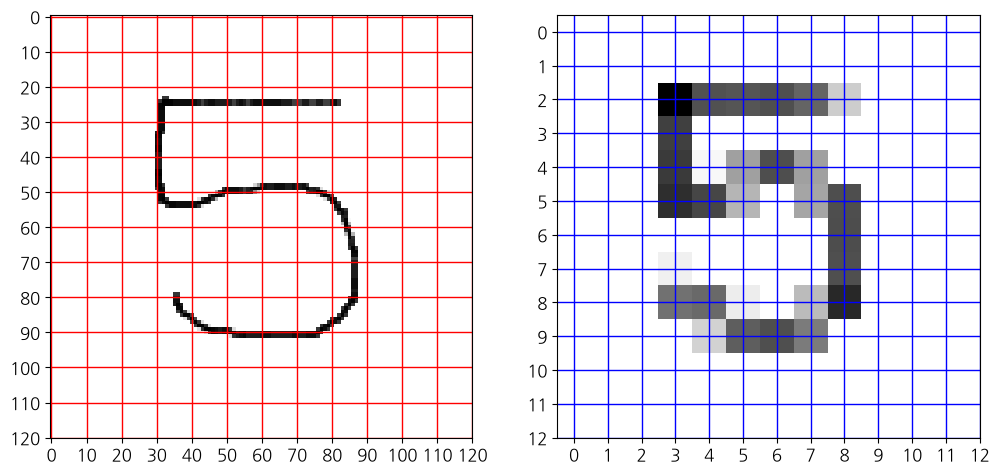

In [34]:
# 이미지를 나란히 출력 : 1행 2열 
fig,axs = plt.subplots(1,2,figsize=(12,6))
# 원본 120x120
axs[0].imshow(img_array,cmap='gray')
axs[0].set_xticks(np.arange(0,121,10))
axs[0].set_yticks(np.arange(0,121,10))
axs[0].grid(True,color='r',linestyle='-', linewidth=1)
# 필터되고 정규화된 이미지 
axs[1].imshow(normal_image,cmap='gray')
axs[1].set_xticks(np.arange(0,13,1))
axs[1].set_yticks(np.arange(0,13,1))
axs[1].grid(True,color='b',linestyle='-', linewidth=1)
plt.show()

<p>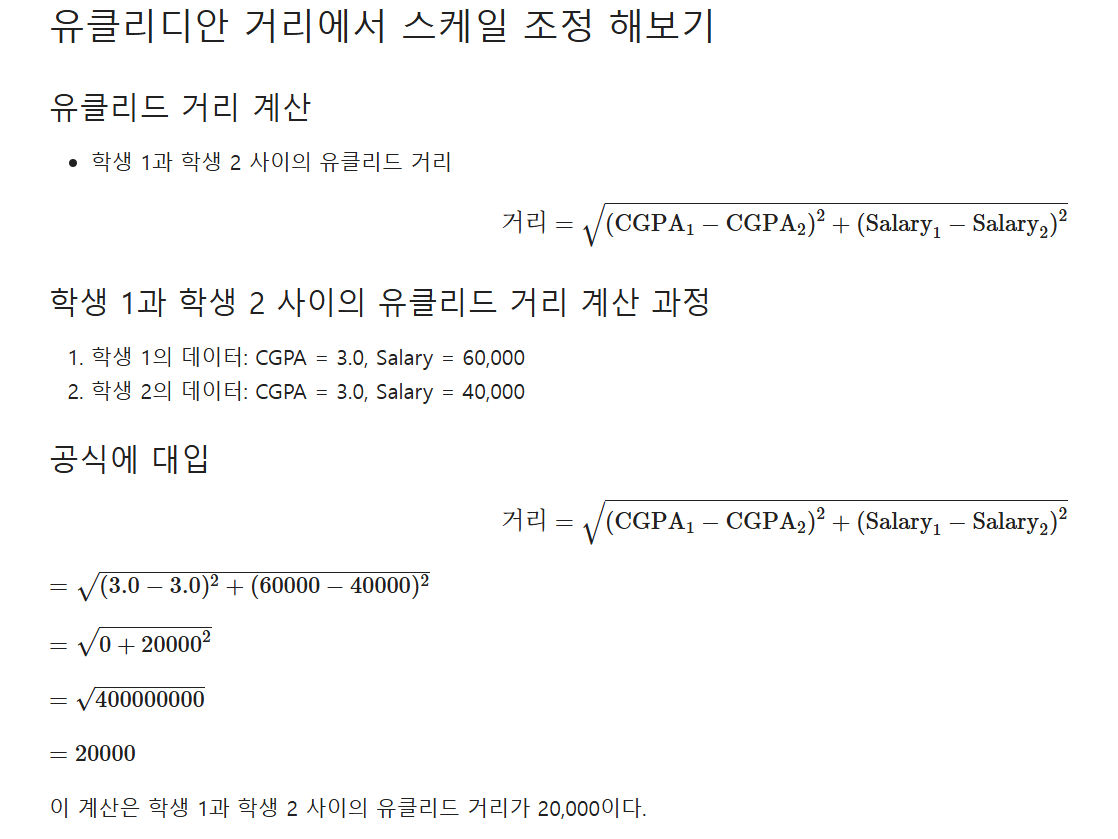</p>

<p>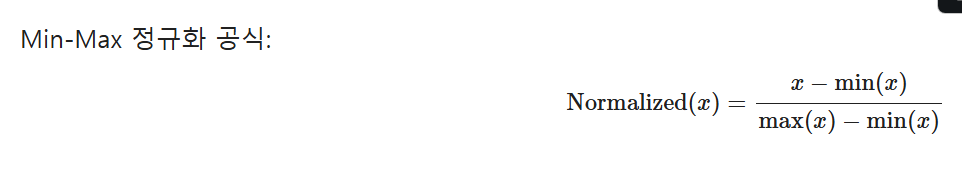</p>

In [35]:
students = np.arange(1,6) # 학번 
cgpa = np.array([3.0, 3.0, 4.0, 4.5, 4.2]) # 학점
salary = np.array([60000, 40000, 40000, 50000, 52000]) # 연봉

In [36]:
# 데이터를 판다스의 데이터 프레임으로 변환 해보세요
# 학생번호 , CGPA , 연봉'
df = pd.DataFrame({'학생번호':students,'CGPA':cgpa,'연봉':salary})
df.head(1)

,학생번호,CGPA,연봉
0,1,3.0,60000


In [37]:
# dataFrame에서 하나의 컬럼을 넘파이 벡터로 변환 
cgpa = df['CGPA'].values
salary =df['연봉'].values

In [38]:
#넘파이 배열의 특징중에 큰값과 작은 값이 같이 있을때
#효율적으로 나타내기 위해서 지수로 표기 해서 출력한다.
data_cgpa_salary = np.array([
    [cgpa[0],salary[0]],
    [cgpa[1],salary[1]],
    [cgpa[2],salary[2]]
])
data_cgpa_salary

array([[3.e+00, 6.e+04],
       [3.e+00, 4.e+04],
       [4.e+00, 4.e+04]])

In [39]:
3.e+00 , 6.e+04

(3.0, 60000.0)

In [40]:
#지수 표기가 보기 어렵다면 지수표기를 해제하고 소수점 자리수 까지 표현
np.set_printoptions(suppress=True,precision=2)

In [41]:
data_cgpa_salary = np.array([
    [cgpa[0],salary[0]],
    [cgpa[1],salary[1]],
    [cgpa[2],salary[2]]
])
data_cgpa_salary

array([[    3., 60000.],
       [    3., 40000.],
       [    4., 40000.]])

In [42]:
cgpa,salary

(array([3. , 3. , 4. , 4.5, 4.2]), array([60000, 40000, 40000, 50000, 52000]))

In [43]:
# 연습문제) numpy에서 배웠던 함수를 사용해서 cgpa,salay를 아래처럼 한번에
# 행렬로 만드시오. hstack , concatenate , for zip 사용할 수도 있고 
comm = """
array([[    3. , 60000. ],
       [    3. , 40000. ],
       [    4. , 40000. ],
       [    4.5, 50000. ],
       [    4.2, 52000. ]])
"""

In [44]:
np.array(list(zip(cgpa,salary)))

array([[    3. , 60000. ],
       [    3. , 40000. ],
       [    4. , 40000. ],
       [    4.5, 50000. ],
       [    4.2, 52000. ]])

In [45]:
#cgpa.reshape(-1,1) , salary.reshape(-1,1)

In [46]:
np.hstack([cgpa.reshape(-1,1),salary.reshape(-1,1)])

array([[    3. , 60000. ],
       [    3. , 40000. ],
       [    4. , 40000. ],
       [    4.5, 50000. ],
       [    4.2, 52000. ]])

In [47]:
np.concatenate((cgpa.reshape(-1,1),salary.reshape(-1,1)),axis=1)

array([[    3. , 60000. ],
       [    3. , 40000. ],
       [    4. , 40000. ],
       [    4.5, 50000. ],
       [    4.2, 52000. ]])

In [48]:
# 1차원 컬럼을  컬럼에 붙여서 행렬 변환 np.column_stack((left,right))
np.column_stack((cgpa,salary))

array([[    3. , 60000. ],
       [    3. , 40000. ],
       [    4. , 40000. ],
       [    4.5, 50000. ],
       [    4.2, 52000. ]])

In [49]:
testData = np.arange(1,10).reshape(3,3)
print(testData)
print(testData.min() , testData.max()) # 1 , 9 - 최소값 
print(testData.min(axis=0))# 열방향 [1 2 3]
print(testData.min(axis=1))# 행방향 [1 4 7]
print(testData.max(axis=0))# 열방향 [7 8 9]
print(testData.max(axis=1))# 행방향 [3 6 9]

[[1 2 3]
 [4 5 6]
 [7 8 9]]
1 9
[1 2 3]
[1 4 7]
[7 8 9]
[3 6 9]


In [50]:
# 함수로 만들어 보기
# 유클리드 거리 계산 함수
# 제곱근 -> np.sqrt() , 2승 -> **2
def my_euclidean(point1,point2):
    return np.sqrt(np.sum(point1 - point2) ** 2)
np.set_printoptions(suppress=True,precision=2)
data_cgpa_salary = np.array([
    [cgpa[0],salary[0]],
    [cgpa[1],salary[1]],
    [cgpa[2],salary[2]]
])
#거리를 각각 구해보자. # 일단 학생 3명만 테스트 해본다.
d_AB = my_euclidean(data_cgpa_salary[0],data_cgpa_salary[1])
d_BC = my_euclidean(data_cgpa_salary[1],data_cgpa_salary[2])
print(f"스케일 전 거리 비교 : {d_AB} , {d_BC}")
print(type(d_AB))
#Min-Max 
#(data - min) / (max - min) 
def min_max(data):
    #axis = 0 : 열방향으로 최소값 , 최대값
    min_val = data.min(axis=0)
    max_val = data.max(axis=0)
    print(min_val,max_val)
    return (data - min_val) / (max_val - min_val)
nRes = min_max(data_cgpa_salary)
nRes
d_AB = my_euclidean(nRes[0],nRes[1])
d_BC = my_euclidean(nRes[1],nRes[2])
print(f"스케일 이후 거리 비교 : {d_AB} , {d_BC}")

스케일 전 거리 비교 : 20000.0 , 1.0
<class 'numpy.float64'>
[    3. 40000.] [    4. 60000.]
스케일 이후 거리 비교 : 1.0 , 1.0


In [51]:
# 사이킷 런에서 제공하는 euclidean_distances
from sklearn.metrics.pairwise import euclidean_distances

In [52]:
data_cgpa_salary = np.array([ # 일단 학생 3명만 테스트 해본다.
     [cgpa[0],salary[0]], 
     [cgpa[1],salary[1]],
     [cgpa[2],salary[2]] 
])
##ValueError: Expected 2D array, got 1D array instead:
d_AB = euclidean_distances(data_cgpa_salary[0].reshape(-1, 1),data_cgpa_salary[1].reshape(-1, 1))
d_BC = euclidean_distances(data_cgpa_salary[1].reshape(-1, 1),data_cgpa_salary[2].reshape(-1, 1))
print(f"스케일 전 거리 비교 : {d_AB} , {d_BC}")
#Min-Max 
#(data - min) / (max - min) 
def min_max(data):
    #axis = 0 : 열방향으로 최소값 , 최대값
    min_val = data.min(axis=0)
    max_val = data.max(axis=0)
    print(min_val,max_val)
    return (data - min_val) / (max_val - min_val)
nRes = min_max(data_cgpa_salary)
d_AB = euclidean_distances([nRes[0]],[nRes[1]])
d_BC = euclidean_distances([nRes[1]],[nRes[2]])
print(f"스케일 이후 거리 비교 : {d_AB} , {d_BC}")

스케일 전 거리 비교 : [[    0. 39997.]
 [59997. 20000.]] , [[    1. 39997.]
 [39996.     0.]]
[    3. 40000.] [    4. 60000.]
스케일 이후 거리 비교 : [[1.]] , [[1.]]


In [53]:
from sklearn.preprocessing import MinMaxScaler

In [54]:
data_cgpa_salary = np.array([ # 일단 학생 3명만 테스트 해본다.
     [cgpa[0],salary[0]], 
     [cgpa[1],salary[1]],
     [cgpa[2],salary[2]] 
])
##ValueError: Expected 2D array, got 1D array instead:
d_AB = euclidean_distances(data_cgpa_salary[0].reshape(-1, 1),data_cgpa_salary[1].reshape(-1, 1))
d_BC = euclidean_distances(data_cgpa_salary[1].reshape(-1, 1),data_cgpa_salary[2].reshape(-1, 1))
print(f"스케일 전 거리 비교 : {d_AB} , {d_BC}")
scaler = MinMaxScaler()
nRes = scaler.fit_transform(data_cgpa_salary)
d_AB = euclidean_distances([nRes[0]],[nRes[1]])
d_BC = euclidean_distances([nRes[1]],[nRes[2]])
print(f"스케일 이후 거리 비교 : {d_AB} , {d_BC}")

스케일 전 거리 비교 : [[    0. 39997.]
 [59997. 20000.]] , [[    1. 39997.]
 [39996.     0.]]
스케일 이후 거리 비교 : [[1.]] , [[1.]]


<h2 id="%ED%9A%8C%EA%B7%80-(Auto-MPG-%EB%8D%B0%EC%9D%B4%ED%84%B0-%EC%85%8B%EC%9C%BC%EB%A1%9C-%EC%9D%91%EC%9A%A9)">회귀 (Auto MPG 데이터 셋으로 응용)¶</h2>
단순 회귀 분석
다중 회귀 분석
데이터셋 다운로드 : https://archive.ics.uci.edu/dataset/9/auto+mpg
카페에 실습데이터 업로드
데이터 셋 설명  mpg는 miles per gallon의 약자로 <연비> 의미한다

  자동차의 연비와 관련된 데이터를 담고 있는 데이터셋

  mpg: 연비

  cylinders: 실린더 개수

  displacement: 배기량

  horsepower: 마력

  weight: 무게

  acceleration: 엔진이 초당 얻을 수 있는 가속력

  model year: 출시 년도

  origin: 제조 장소(1: 미국 USA, 2: 유럽 EU, 3: 일본 JPN)

  car name: 자동차 이름

<p>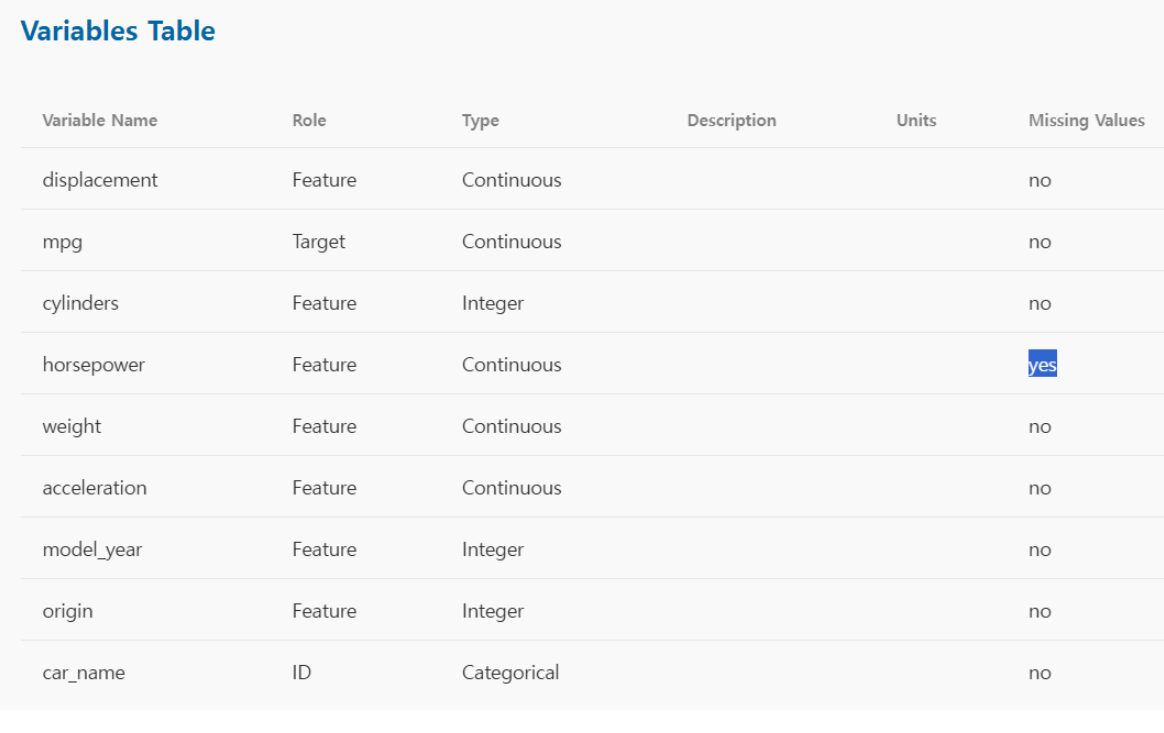</p>

In [55]:
os.listdir('dataset')

['five.png', 'linear.csv', 'rabbit.jpg']

In [58]:
'''
[Step 1] 데이터 준비 - read_csv() 함수로 자동차 연비 데이터셋 가져오기
'''
df = pd.read_csv('dataset/auto-mpg.csv')
df
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
 'acceleration','model year','origin','name']

In [59]:
df.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name
0,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
1,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite


In [60]:
"""
[Step 2] 데이터 탐색 : 데이터의 Nan여부, 중복데이터 , 특이점, 시각화 전처리 등을 포함
"""
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    397 non-null    str    
 4   weight        397 non-null    float64
 5   acceleration  397 non-null    float64
 6   model year    397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.0 KB


In [61]:
# 데이터 자료형을 확인 - 수치형인데 str이면 뭔가 문제가 있다 
df['horsepower']

0      165.0
1      150.0
2      150.0
3      140.0
4      198.0
       ...  
392    86.00
393    52.00
394    84.00
395    79.00
396    82.00
Name: horsepower, Length: 397, dtype: str

In [62]:
#null
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
name            0
dtype: int64

In [63]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'name'],
      dtype='str')

In [64]:
# 통계 요약 정보
# horsepower 가 빠졌음을 확인 , 요약정보는 숫자형 데이터여야 출력이 된다.
# name은 관심사가 아님
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000
mean,23.528463,5.448363,193.139798,2969.080605,15.577078,76.025189,1.574307
std,7.820926,1.698329,104.244898,847.485218,2.755326,3.689922,0.802549
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.000000,2223.000000,13.900000,73.000000,1.000000
50%,23.000000,4.000000,146.000000,2800.000000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3609.000000,17.200000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [65]:
# 문자열을 실수형으로 변환해보자. -> df['col'].astype('자료형')
#ValueError: could not convert string to float: '?'
#df['horsepower'].astype('float')

In [66]:
# horsepower 열의 고유값 확인하니 '?' 가 보인다.
df['horsepower'].unique()

<StringArray>
['165.0', '150.0', '140.0', '198.0', '220.0', '215.0', '225.0', '190.0',
 '170.0', '160.0', '95.00', '97.00', '85.00', '88.00', '46.00', '87.00',
 '90.00', '113.0', '200.0', '210.0', '193.0',     '?', '100.0', '105.0',
 '175.0', '153.0', '180.0', '110.0', '72.00', '86.00', '70.00', '76.00',
 '65.00', '69.00', '60.00', '80.00', '54.00', '208.0', '155.0', '130.0',
 '112.0', '92.00', '145.0', '137.0', '158.0', '167.0', '94.00', '107.0',
 '230.0', '49.00', '75.00', '91.00', '122.0', '67.00', '83.00', '78.00',
 '52.00', '61.00', '93.00', '148.0', '129.0', '96.00', '71.00', '98.00',
 '115.0', '53.00', '81.00', '79.00', '120.0', '152.0', '102.0', '108.0',
 '68.00', '58.00', '149.0', '89.00', '63.00', '48.00', '66.00', '139.0',
 '103.0', '125.0', '133.0', '138.0', '135.0', '142.0', '77.00', '62.00',
 '132.0', '84.00', '64.00', '74.00', '116.0', '82.00']
Length: 94, dtype: str

In [67]:
df['horsepower'].replace('?',np.nan,inplace=True)

0      165.0
1      150.0
2      150.0
3      140.0
4      198.0
       ...  
392    86.00
393    52.00
394    84.00
395    79.00
396    82.00
Name: horsepower, Length: 397, dtype: str

In [68]:
df['horsepower'].isnull().sum()

np.int64(0)

In [69]:
#'?' => np.nan으로 변경 .replace('?',변경값) , 버전이 변경된 관계로 ,inplace=True 적용안된다.
df['horsepower'] = df['horsepower'].replace('?',np.nan)

In [70]:
df['horsepower'].isnull().sum()

np.int64(6)

In [71]:
# df['horsepower'].unique()

In [72]:
len(df['horsepower']) - 6

391

In [73]:
#행 삭제 -> df.dropna(subset=[col],axis=0,inplace=True)
df.dropna(subset=['horsepower'],axis=0,inplace=True)

In [74]:
len(df)

391

In [75]:
df['horsepower'].isnull().sum()

np.int64(0)

In [76]:
df['horsepower'] = df['horsepower'].astype('float')

In [77]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 391 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           391 non-null    float64
 1   cylinders     391 non-null    int64  
 2   displacement  391 non-null    float64
 3   horsepower    391 non-null    float64
 4   weight        391 non-null    float64
 5   acceleration  391 non-null    float64
 6   model year    391 non-null    int64  
 7   origin        391 non-null    int64  
 8   name          391 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 30.5 KB


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000
mean,23.459847,5.465473,194.124041,104.404092,2976.237852,15.550384,75.994885,1.578005
std,7.810128,1.703152,104.622462,38.518732,850.071941,2.756557,3.675975,0.806020
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2224.500000,13.800000,73.000000,1.000000
50%,23.000000,4.000000,151.000000,93.000000,2800.000000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,264.500000,125.000000,3616.500000,17.050000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [78]:
'''
[Step 3] 속성(feature 또는 variable) 선택
어떤 것이 연비와 관련이 있는지를 컬럼 재정의를 한다.
'''
ndf = df[['mpg','cylinders','horsepower','weight']]
ndf.head(2)

,mpg,cylinders,horsepower,weight
0,15.0,8,165.0,3693.0
1,18.0,8,150.0,3436.0


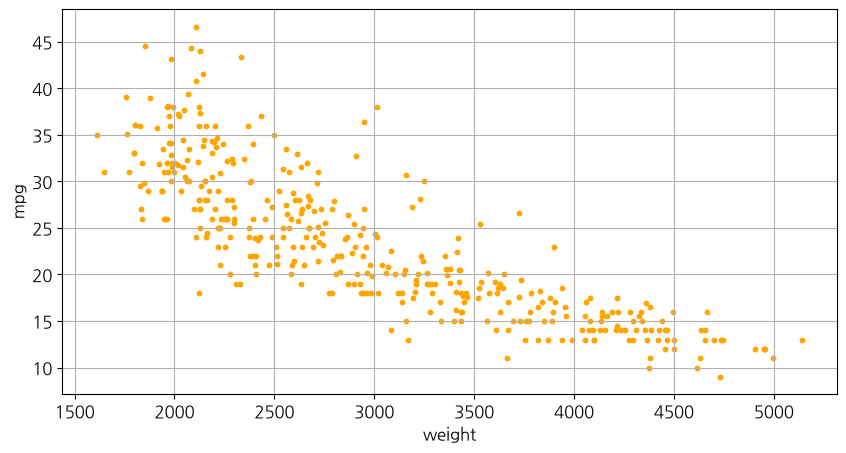

'\ncylinders(cylinders) 과 연비(mpg)의 상관관계\n'

In [79]:
'''
[Step 4] feature 와 tager의  선형관계를 그래프(산점도)로 확인
무게(weight) 과 연비(mpg)의 상관관계
'''
ndf.plot(kind='scatter',x='weight',y='mpg',c='orange',s=10,figsize=(10,5))
plt.grid()
plt.show()
'''
cylinders(cylinders) 과 연비(mpg)의 상관관계
'''

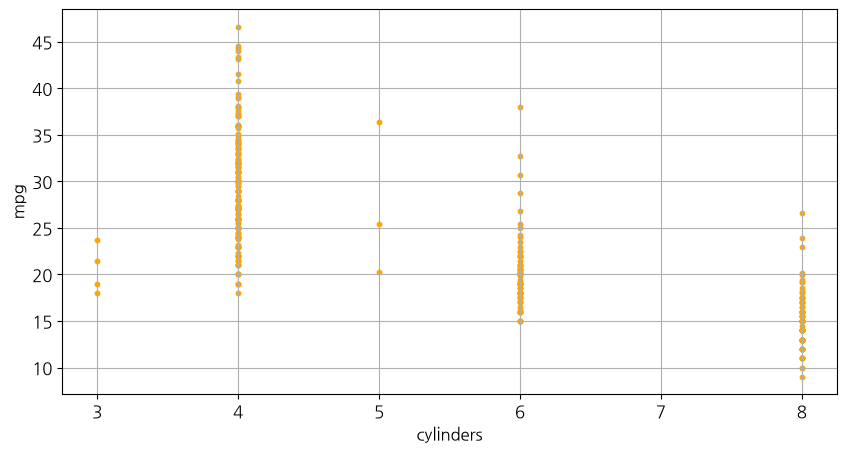

In [80]:
ndf.plot(kind='scatter',x='cylinders',y='mpg',c='orange',s=10,figsize=(10,5))
plt.grid()
plt.show()

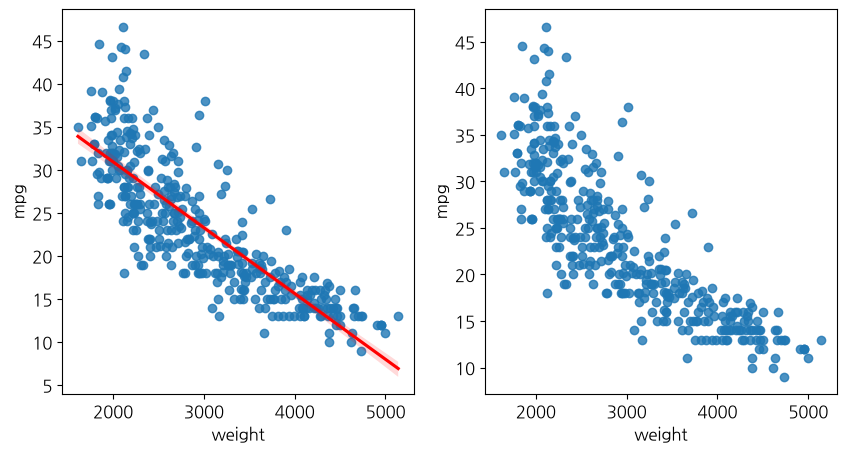

In [81]:
#Seaborn을 사용한 회귀plot -> regplot , line_kws => 회귀선 그려준다.
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
sns.regplot(x='weight',y='mpg',data=df,ax=ax1,line_kws=dict(color='r'))
sns.regplot(x='weight',y='mpg',data=df,ax=ax2,fit_reg=False)
plt.show()

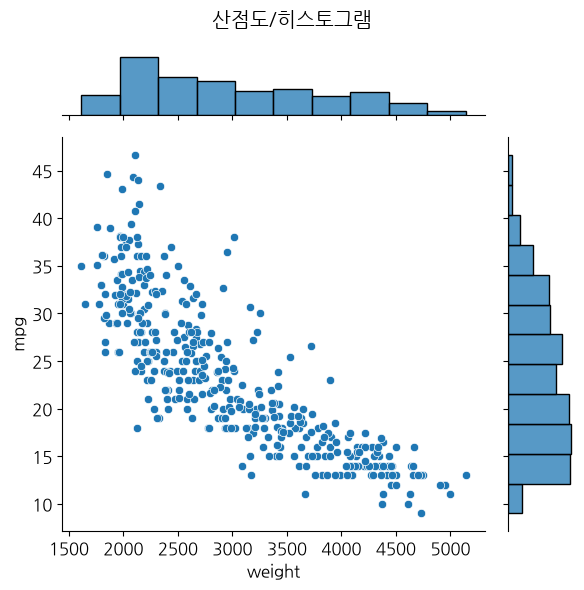

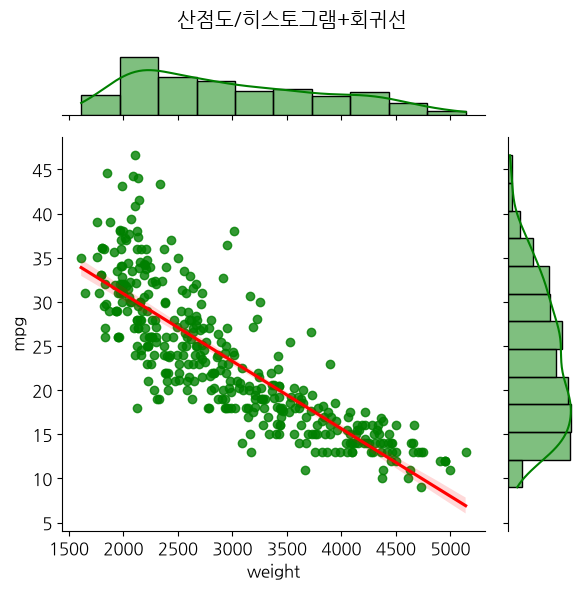

In [82]:
jp1 = sns.jointplot(x='weight',y='mpg', data=ndf)
#matplotlib.figure.Figure
type(jp1.fig)
jp1.fig.suptitle('산점도/히스토그램')
jp1.fig.tight_layout()
jp2 = sns.jointplot(x='weight',y='mpg', data=ndf, kind='reg',line_kws=dict(color="r"),\
                   color='g')
jp2.fig.suptitle('산점도/히스토그램+회귀선')
jp2.fig.tight_layout()
plt.show()

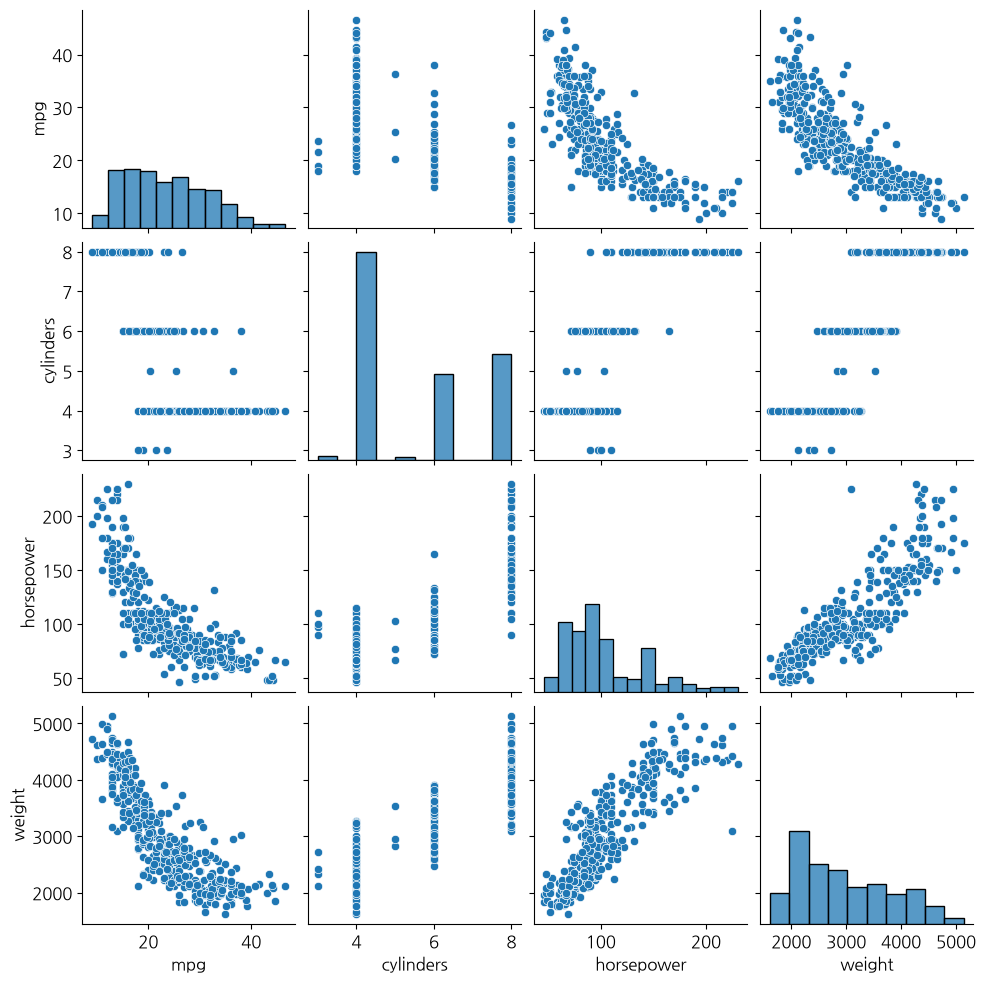

In [83]:
#seaborn pariplot으로 두 변수 간의 모든 경우의 수 그리기
sns.pairplot(ndf)
plt.show()

In [84]:
'''
Step 5: <데이터 분할 및 모델 준비> 데이터셋 구분 및 과적합을 방지 하기 위해서 데이터셋 분리
        => 훈련용(train data)/ 검증용(test data)
 - train_test_split함수를 사용해서 학습 데이터 셋과 테스트 데이터 셋을 분할 할 때
                무작위로 섞은 후에 지정한 비율에 따라 분할 해줌
 - random_state :  결과를 재현 가능하게 만들어 동일한 난수 초기값에서 시작하기 때문에
                코드를 실행할 때마다 동일한 방식으로 데이터가 분할
'''
#1) 독립/종속
X = ndf[['weight']] #DataFrame -> 2D
y = ndf['mpg']
#2) 데이터 분할
# 반환 값 정도는 외워 두기 바람 
# 독립변수(train,test), 종속변수(train,test) = train_test_split()
# test_size 검증 30% => 7:3 비율로 데이터를 섞어서 나눈다.
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)
print(f'train data 개수: {len(X_train)} , {type(X_train)}')
print(f'test data 개수: {len(X_test)}')

train data 개수: 273 , <class 'pandas.DataFrame'>
test data 개수: 118


In [85]:
X_train.head(2)
X_test.head(2)

,weight
94,4951.0
193,3085.0


In [86]:
#'pandas.Series'
X_train.values.ndim

2

In [92]:
'''
Step 6: 단순 회귀분석 모형 - sklearn 사용
lr.fit(TrainX,TrainY)
'''
lr = LinearRegression()      
lr.fit(X_train, y_train)     
test_pred = lr.predict(X_test)

In [93]:
'''
Step 7: 학습을 마치고 나서 따로 분할 해놓은 test_X,test_Y를 가지고 점수를 평가
'''
# 학습률 / 테스트 점수 
trainScore = lr.score(X_train,y_train)
testScore = lr.score(X_test,y_test)
trainScore ,testScore

(0.6837311330480664, 0.7075039478671745)

기울기 : -0.007497803857336669
절편 : 45.70816425201444


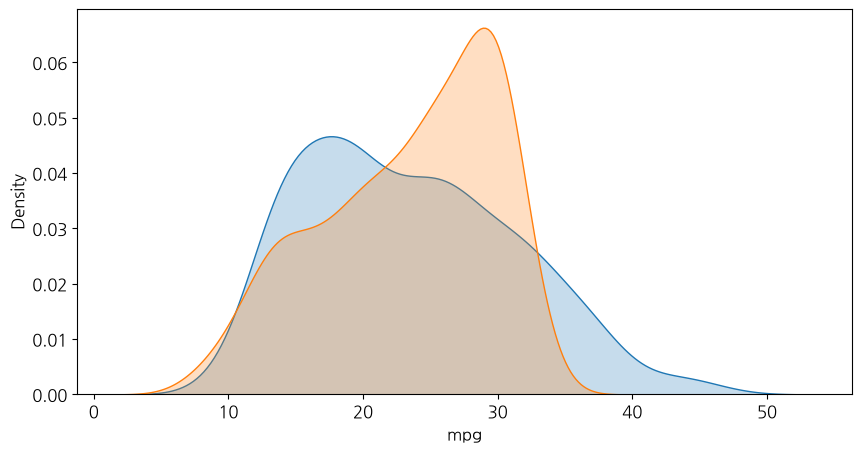

In [94]:
'''
Step 8: 시각화(선택), 예측 
'''
print(f"기울기 : {lr.coef_[0]}")
print(f"절편 : {lr.intercept_}")
y_hat = lr.predict(X)
# y - y_hat
# 오차 : 예측한 값 y_hat을 실제 값 y와 비교하기 위한 시각화
plt.figure(figsize=(10, 5))
ax1 = sns.kdeplot(y,label='y',fill=True)
# ax=ax1을 설정하여 y의 KDE 플롯과 같은 그래프에 그리기 - 비교하기 위함
ax2 = sns.kdeplot(y_hat,label='y_hat',ax=ax1,fill=True)
plt.show()

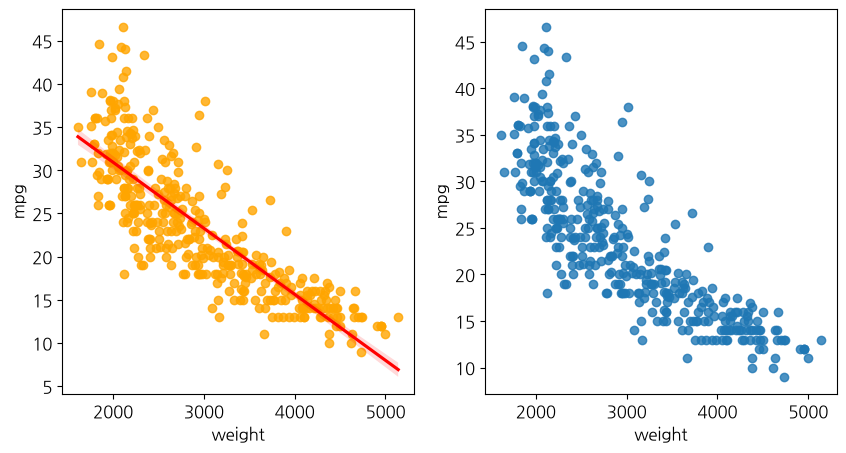

In [95]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
sns.regplot(x='weight',y='mpg',data=df,ax=ax1, color='orange',line_kws=dict(color='r'))
sns.regplot(x='weight',y='mpg',data=df,ax=ax2,fit_reg=False)
plt.show()

<p>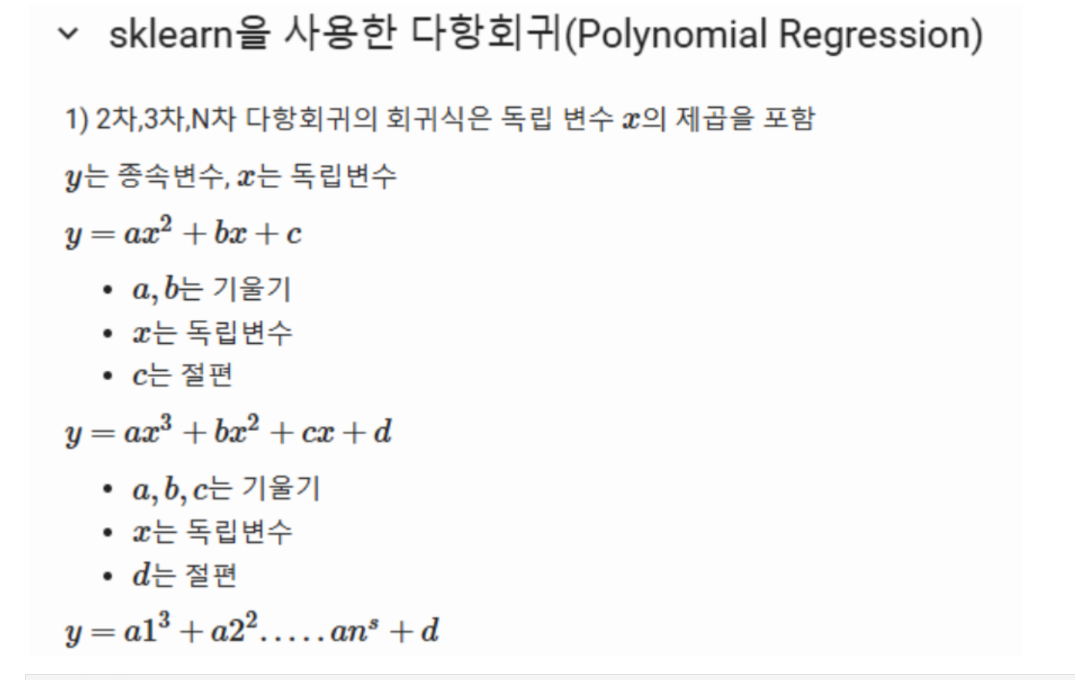</p>

In [96]:
ndf.isnull().sum()

mpg           0
cylinders     0
horsepower    0
weight        0
dtype: int64

In [97]:
'''
Step 5: <데이터 분할 및 모델 준비> 데이터셋 구분 및 과적합을 방지 하기 위해서 데이터셋 분리
        => 훈련용(train data)/ 검증용(test data)
 - train_test_split함수를 사용해서 학습 데이터 셋과 테스트 데이터 셋을 분할 할 때
                무작위로 섞은 후에 지정한 비율에 따라 분할 해줌
 - random_state :  결과를 재현 가능하게 만들어 동일한 난수 초기값에서 시작하기 때문에
                코드를 실행할 때마다 동일한 방식으로 데이터가 분할
'''
#1) 독립/종속
X = ndf[['weight']] #DataFrame -> 2D
y = ndf['mpg']
#2) 데이터 분할
# 반환 값 정도는 외워 두기 바람 
# 독립변수(train,test), 종속변수(train,test) = train_test_split()
# test_size 검증 30% => 7:3 비율로 데이터를 섞어서 나눈다.
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)
print(f'train data 개수: {len(X_train)} , {type(X_train)}')
print(f'test data 개수: {len(X_test)}')
print(f"X의 Shape {X_train.shape} , X의 차원 {X.ndim}")

train data 개수: 273 , <class 'pandas.DataFrame'>
test data 개수: 118
X의 Shape (273, 1) , X의 차원 2


In [98]:
'''
Step 6: 단순회귀분석 모형, 다항회귀모델 (PolynomialFeatures) - sklearn 사용
'''
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures  # 다항회귀 모듈

In [99]:
# numpy 함수 
# np.linspace(시작,종료,나눌값 )
# 시작점, 종료점,간격내 숫자
# 시작점 0에서 100까지 3개로 나눈 값
np.linspace(0,100,3) , np.linspace(0,100,8)

(array([  0.,  50., 100.]),
 array([  0.  ,  14.29,  28.57,  42.86,  57.14,  71.43,  85.71, 100.  ]))

In [101]:
def mylinspace(start,end, num):
    if num == 1:
        return [start]
    step = (end - start ) / (num - 1)
    return [ start + step * i for i in range(num)]
mySpace = mylinspace(0,100,5)
mySpace

[0.0, 25.0, 50.0, 75.0, 100.0]

In [102]:
# 다항식에서 차수값 
# degree=1 : 선형관계
# degree=2 : 2차항 까지 생성, 곡선 형태의 비선형 
# degree=3 : 3차항 까지 생성 , 비선형관계 
# include_bias=False , 절편을 포함 안한다.
polyreg  = PolynomialFeatures(degree=2,include_bias=False)
X_train_poly = polyreg.fit_transform(X_train)
X_test_poly = polyreg.transform(X_test)
lr = LinearRegression()
# fit() : 학습 이니까 train x, y
lr.fit(X_train_poly,y_train)
# score : 훈련용 - train x,y | 검증용 - test x, y
r_sq = lr.score(X_test_poly,y_test)
print(f"테스트 데이터에 대한 예측 점수 :{r_sq}")

테스트 데이터에 대한 예측 점수 :0.7306822529783035


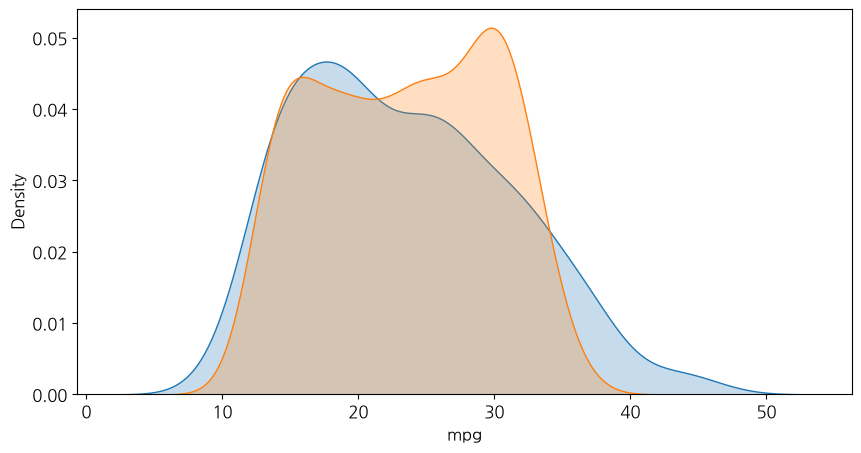

In [103]:
'''
Step 8: 시각화(선택), 예측 
'''
X_poly = polyreg.transform(X)
y_hat = lr.predict(X_poly)
# y - y_hat
# 오차 : 예측한 값 y_hat을 실제 값 y와 비교하기 위한 시각화
plt.figure(figsize=(10, 5))
ax1 = sns.kdeplot(y,label='y',fill=True)
# ax=ax1을 설정하여 y의 KDE 플롯과 같은 그래프에 그리기 - 비교하기 위함
ax2 = sns.kdeplot(y_hat,label='y_hat',ax=ax1,fill=True)
plt.show()

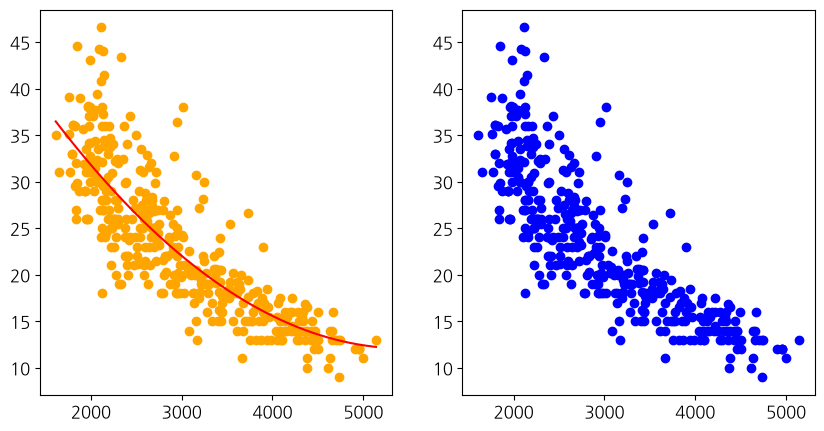

In [104]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

x_seq = np.linspace(ndf['weight'].min(),ndf['weight'].max(),300).reshape(-1,1)
y_pred = lr.predict(polyreg.transform(x_seq))

ax1.scatter(ndf['weight'],ndf['mpg'],color='orange')
ax1.plot(x_seq,y_pred,color='red')
# sns.regplot(x='weight',y='mpg',data=df,ax=ax1, color='orange',line_kws=dict(color='r'))
# sns.regplot(x='weight',y='mpg',data=df,ax=ax2,fit_reg=False)
ax2.scatter(ndf['weight'],ndf['mpg'],color='blue')
plt.show()

In [105]:
#<연습문제>
# step1. 데이터 프레임으로 변환시키기
weight=[ 72, 72, 70, 43, 48, 54, 51, 52, 73, 45, 60, 62, 64, 47, 51, 74, 88,64, 56, 56  ]
tall = [ 176, 172, 182, 160, 163, 165, 168, 163, 182, 148, 170, 166, 172, 169, 163, 170, 182, 174, 164, 160 ]

dict_data = { 'weight' : [ 72, 72, 70, 43, 48, 54, 51, 52, 73, 45, 60, 62, 64, 47, 51, 74, 88, 64, 56, 56  ],
                  'tall' : [ 176, 172, 182, 160, 163, 165, 168, 163, 182, 148, 170, 166, 172, 169, 163, 170, 182, 174, 164, 160 ]   }

In [106]:
#Step 2: 데이터셋 구분 - 훈련용(train data)/ 검증용(test data)
# 속성(변수) 선택
# train data 와 test data로 구분(9:1 비율)
# 데이터 양이 적기 때문에 9대 1로 나눠줌
#시드값을 10으로 고정

In [107]:
#Step 3: 단순회귀분석 모형 - sklearn 사용
# sklearn 라이브러리에서 선형회귀분석 모듈 가져오기
# 학습데이터를 가지고 훈련 *****
#Step 4 학습을 마친 후 test데이터로 검증

#Step 5 예측
# 모형에 전체 X 데이터를 입력하여 예측한 값 y_hat을 실제 값 y와 비교

#Step 6 시각화
# 독립변수의 범위 설정

#Step 6-1 오차 시각화

#Step 6-2 산점도 그리기

# 1열에 산점도 그리기
#---------------------------------------------------------
# 다항회귀 적용하기
#Test score :0.9263965046109203

In [108]:
#풀이)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# step1. 데이터 프레임으로 변환시키기
weight=[ 72, 72, 70, 43, 48, 54, 51, 52, 73, 45, 60, 62, 64, 47, 51, 74, 88,64, 56, 56  ]
tall = [ 176, 172, 182, 160, 163, 165, 168, 163, 182, 148, 170, 166, 172, 169, 163, 170, 182, 174, 164, 160 ]

dict_data = { 'weight' : [ 72, 72, 70, 43, 48, 54, 51, 52, 73, 45, 60, 62, 64, 47, 51, 74, 88, 64, 56, 56  ],
                  'tall' : [ 176, 172, 182, 160, 163, 165, 168, 163, 182, 148, 170, 166, 172, 169, 163, 170, 182, 174, 164, 160 ]   }

df = pd.DataFrame(dict_data)
df.head()

,weight,tall
0,72,176
1,72,172
2,70,182
3,43,160
4,48,163


In [109]:
#df.info()
#df.isnull().sum()
#df.describe()

In [110]:
#Step 2: 데이터셋 구분 - 훈련용(train data)/ 검증용(test data)
# 속성(변수) 선택
X=df[['weight']] #독립 변수 X
y=df['tall'] #종속 변수 Y
# train data 와 test data로 구분(9:1 비율)
# 데이터 양이 적기 때문에 9대 1로 나눠줌
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, #독립 변수
 y, #종속 변수
 test_size=0.1, #검증 10%
 random_state=10) #시드값을 10으로 고정
print('train data 개수: ', len(X_train)) #18개
print('test data 개수: ', len(X_test)) #2개

train data 개수:  18
test data 개수:  2


Test score :0.8657609246754262
기울기 a:  [0.58]
y절편 b 133.84081287044876


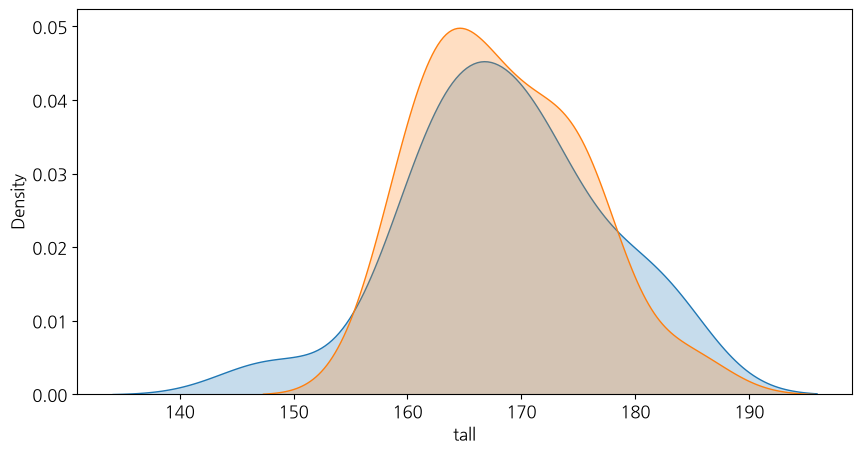

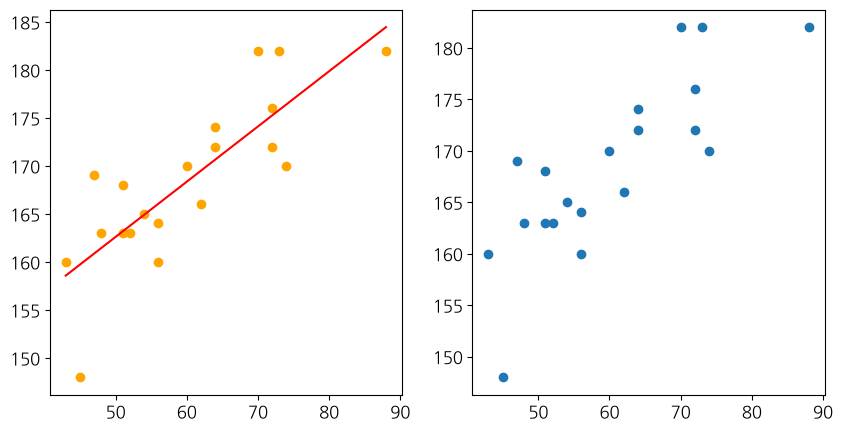

In [111]:
#Step 3: 단순회귀분석 모형 - sklearn 사용
# sklearn 라이브러리에서 선형회귀분석 모듈 가져오기
from sklearn.linear_model import LinearRegression
# 단순회귀분석 모형 객체 생성
lr = LinearRegression()
# 학습데이터를 가지고 훈련 *****
lr.fit(X_train, y_train)
#Step 4 학습을 마친 후 test데이터로 검증
r_square = lr.score(X_test, y_test)
print(f'Test score :{r_square}')
print('기울기 a: ', lr.coef_)
print('y절편 b', lr.intercept_)
#Step 5 예측
# 모형에 전체 X 데이터를 입력하여 예측한 값 y_hat을 실제 값 y와 비교
y_hat = lr.predict(X)
#Step 6 시각화
# 독립변수의 범위 설정
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1,1)
# 회귀선 계산: y = mx + b
m = lr.coef_[0]  # 기울기
b = lr.intercept_ # y절편
y_line = m * X_range + b
#Step 6-1 오차 시각화
plt.figure(figsize=(10, 5))
ax1 = sns.kdeplot(y, label="y", fill=True)
ax2 = sns.kdeplot(y_hat, label="y_hat", fill=True, ax=ax1)
#Step 6-2 산점도 그리기
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
# 1열에 산점도 그리기
ax1.scatter(df['weight'], df['tall'], color='orange')
ax1.plot(X_range, y_line, color='red', label='Regression Line') #회귀선
ax2.scatter(df['weight'], df['tall'])
plt.show()

In [112]:
polyreg = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = polyreg.fit_transform(X_train)
X_test_poly = polyreg.transform(X_test)
X_poly = polyreg.transform(X)
lr = LinearRegression()
lr.fit(X_train_poly, y_train)
r_square = lr.score(X_test_poly, y_test)

Test score :0.9263965046109223
기울기: [ 1.14 -0.  ]
y절편: 116.73144020415813


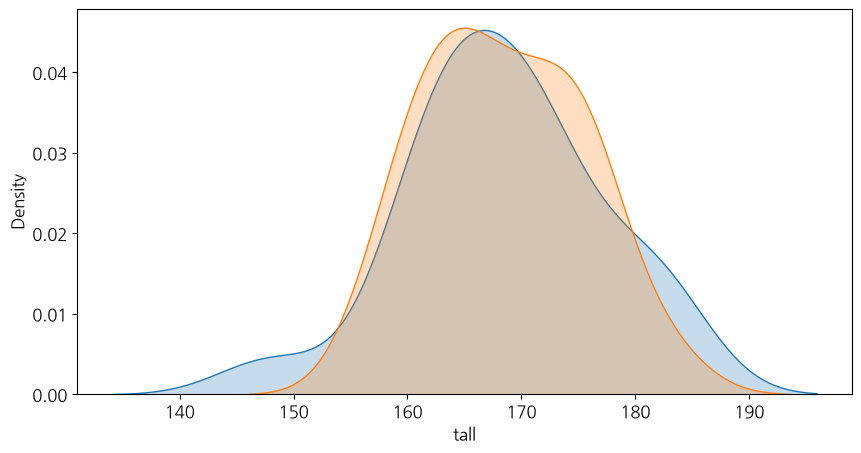

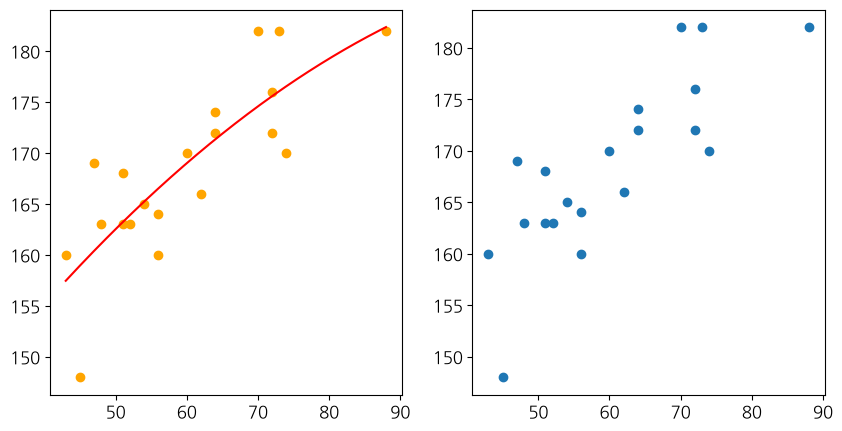

In [113]:
print(f'Test score :{r_square}')
print('기울기:', lr.coef_)
print('y절편:', lr.intercept_)
y_hat_poly = lr.predict(X_poly)
X_range_poly = polyreg.transform(np.linspace(X.min(), X.max(), 300).reshape(-1, 1))
y_line_poly = lr.predict(X_range_poly)
#Kde
plt.figure(figsize=(10, 5))
ax1 = sns.kdeplot(y, label="y", fill=True)
ax2 = sns.kdeplot(y_hat_poly, label="y_hat", fill=True, ax=ax1)
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
ax1.scatter(X, y, color='orange')
ax1.plot(np.linspace(X.min(), X.max(), 300), y_line_poly, color='red', label='Polynomial Regression Line')
ax2.scatter(X, y)
plt.show()
plt.close()